In [29]:
import requests
from bs4 import BeautifulSoup
import json
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def lade_html(url) -> str:
    if url.startswith("/"):
        url = "https://en.wikipedia.org" + url
    return requests.get(url).text

def lade_seite(url):
    return BeautifulSoup(lade_html(url), features="html.parser").body

def get_table(url):
    body = lade_seite(url)
    tables = body.find_all("table")
    tables = list(filter(lambda tab: "class" in tab.attrs and "infobox" in tab["class"], tables))
    if len(tables) == 0:
        return None
    else:
        return tables[0]

def get_table_value(table, argument):
    for line in table.find_all("tr"):
        cells = line.find_all("td") + line.find_all("th")
        if len(cells) == 0:
            continue
        param = cells[0].text\
                        .replace("\n", "")\
                        .replace("\t", "")\
                        .replace(":", "")
        if param == argument:
            return line.nextSibling.find("td")

def get_links(cell):
    if cell is None:
        return
    links = cell.find_all("a")
    for a in links:
        if a.parent.name == "sup":
            continue
        if a["href"].startswith("/"):
            yield a.text, a["href"]

def get_infos(name, url, queue, output):
    if url in queue:
        del queue[url]
    infos = {"name": name, "von": [], "zu": []}
    table = get_table(url)
    if table is None:
        return infos
    von = get_links(get_table_value(table, "Influenced by"))
    zu = get_links(get_table_value(table, "Influenced"))
    for key, values in zip(["von", "zu"], [von, zu]):
        for name_, url_ in values:
            infos[key].append(url_)
            if url_ not in queue and url_ not in output:
                queue[url_] = name_
    print(name)
    return infos

In [31]:
queue = {"/wiki/Python_(programming_language)": "Python"}
ausgabe = {}

while len(queue) > 0:
    url = list(queue.keys())[0]
    ausgabe[url] = get_infos(queue[url], url, queue, ausgabe)

with open("sprachen.json", "w") as f:
    json.dump(ausgabe, f, indent=2)

C:\Users\Felix\AppData\Local\Temp\ipykernel_12896\1330790743.py:28: DeprecationWarning: Access to deprecated property nextSibling. (Replaced by next_sibling) -- Deprecated since version 4.0.0.
  cell = line.nextSibling.find("td")


<td class="infobox-full-data" colspan="2"><a href="/wiki/ABC_(programming_language)" title="ABC (programming language)">ABC</a>,<sup class="reference" id="cite_ref-faq-created_12-0"><a href="#cite_note-faq-created-12"><span class="cite-bracket">[</span>12<span class="cite-bracket">]</span></a></sup> <a href="/wiki/Ada_(programming_language)" title="Ada (programming language)">Ada</a>,<sup class="reference" id="cite_ref-13"><a href="#cite_note-13"><span class="cite-bracket">[</span>13<span class="cite-bracket">]</span></a></sup> <a href="/wiki/ALGOL_68" title="ALGOL 68">ALGOL 68</a>,<sup class="reference" id="cite_ref-98-interview_14-0"><a href="#cite_note-98-interview-14"><span class="cite-bracket">[</span>14<span class="cite-bracket">]</span></a></sup> <br/><a href="/wiki/APL_(programming_language)" title="APL (programming language)">APL</a>,<sup class="reference" id="cite_ref-python.org_15-0"><a href="#cite_note-python.org-15"><span class="cite-bracket">[</span>15<span class="cite-br

In [32]:
with open("sprachen.json", "r") as f:
    ausgabe = json.load(f)
kanten = []
counter = {sprache: 0 for sprache in [e["name"] for e in ausgabe.values()]}
G = nx.DiGraph()
for url in ausgabe:
    name = ausgabe[url]["name"]
    neue_kanten = []
    for url_ in ausgabe[url]["von"]:
        neue_kanten.append((ausgabe[url_]["name"], name))
    for url_ in ausgabe[url]["zu"]:
        neue_kanten.append((name, ausgabe[url_]["name"]))
    for von, zu in neue_kanten:
        if (von, zu) not in kanten:
            kanten.append((von, zu))
            counter[von] += 1
            counter[zu] += 1

MINIMUM_COUNT = 8

for url in ausgabe:
    name = ausgabe[url]["name"]
    if counter[name] >= MINIMUM_COUNT:
        G.add_node(name)
for von, zu in kanten:
    if counter[von] >= MINIMUM_COUNT and counter[zu] >= MINIMUM_COUNT:
        G.add_edge(von, zu)

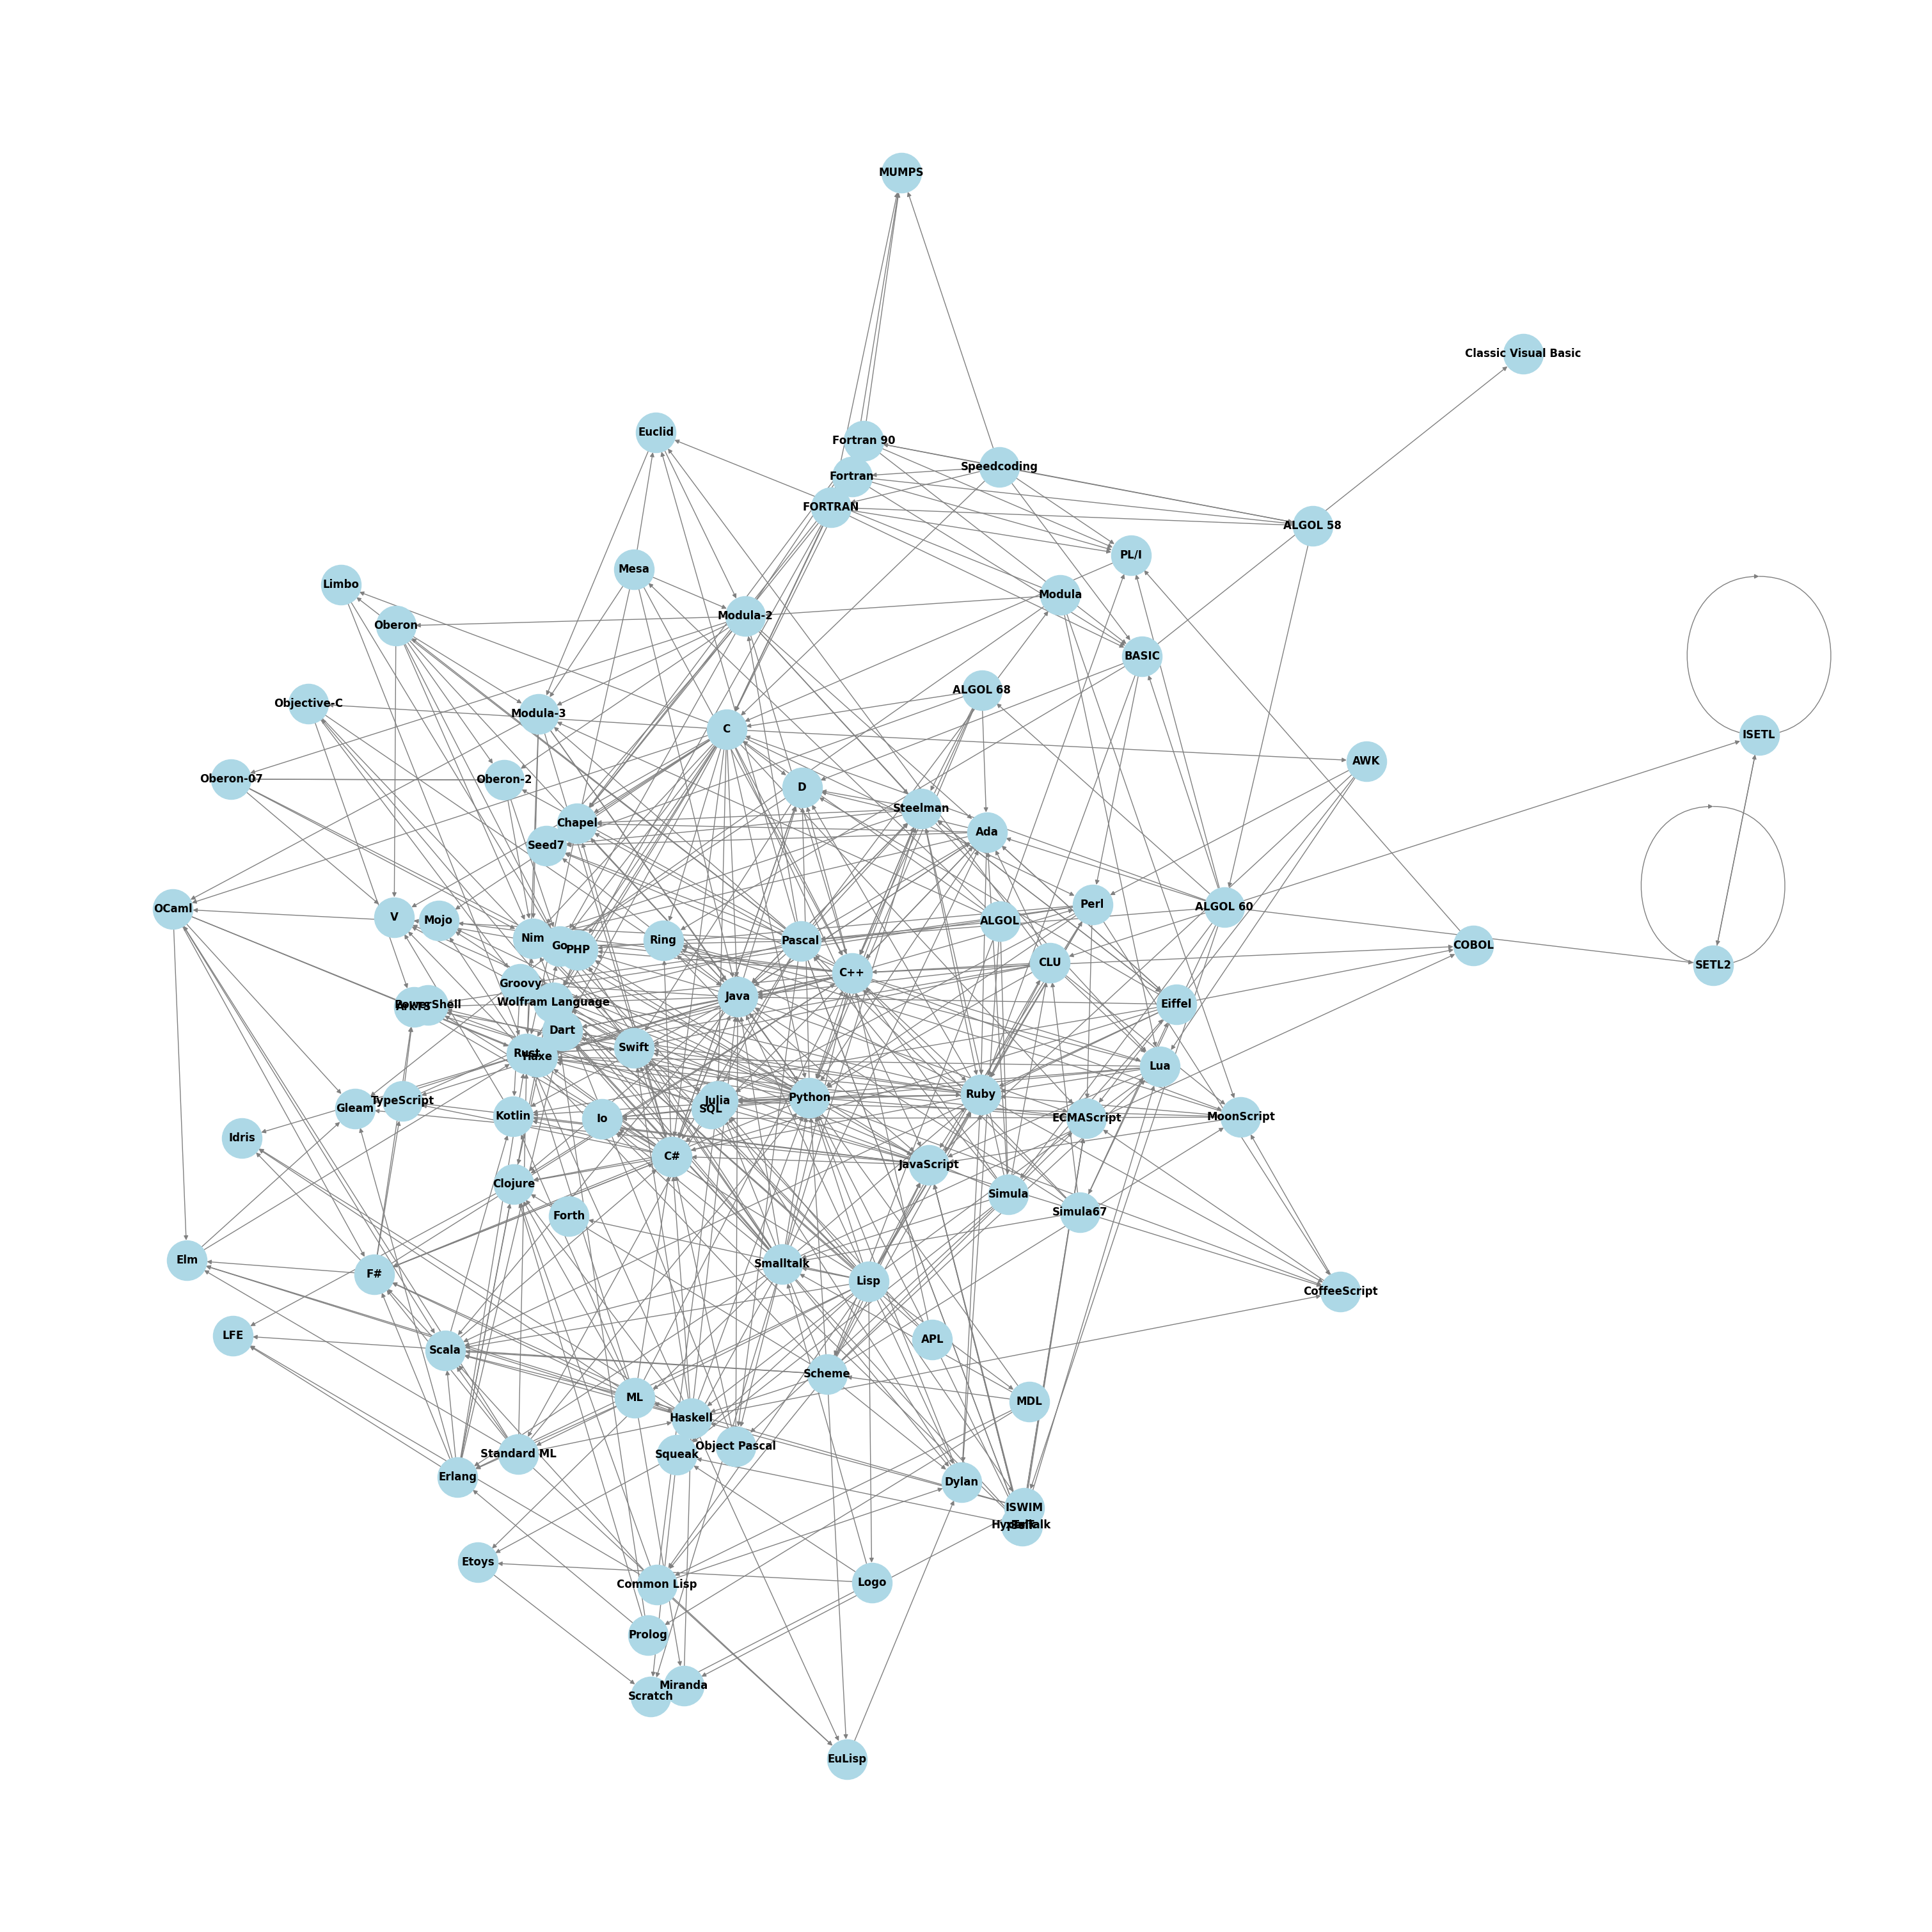

In [33]:
plt.figure(figsize=(30, 30))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=12, font_weight="bold", arrows=True)
plt.show()